In [4]:
#%pip install torch
import torch

In [5]:
import pandas as pd

In [6]:

from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
import nltk, string, random, numpy, os
import matplotlib.pyplot as plt
from typing import List
os.makedirs('./results', exist_ok=True)
nltk.download('brown')
from nltk.corpus import brown
random.seed(42)
torch.manual_seed(42)
numpy.random.seed(42)

[nltk_data] Downloading package brown to
[nltk_data]     /Users/alicjadorobis/nltk_data...
[nltk_data]   Package brown is already up-to-date!


### Introduction
In the warm-up of this assignment, we will see how Neural Networks (NN) handle natural language data.   
The warm-up focuses on a simple Multilayer Perceptron (MLP), also known as a fully connected Neural Network. The data we'll use is the first 5000 unique words of the Brown corpus.

### Dataset
To train the model, we will have to represent the input words to the model in some way. Since models solely work with numbers, the words will have to be converted into numerical form.  
For this assignment, we will focus on predicting individual words from the dataset given the input of the model. The input will be the target word split up into individual letters. To represent these individual letters we will give the model a vector of 26 positions (26 letters in the English alphabet). Initially, this vector is filled with zeros and for every occuring letter in the word we change the value to 1 in that position. For instance, in the word `apple', we have 1 a, 1 e, 1 l and 2 p. The vector will then represent the word as:  
```[1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,2,0,0,0,0,0,0,0,0,0,0]```  
You will have to implement this algorithm together with loading the Brown dataset and taking the first 5000 unique words. Implement a way to store the indexes of the unique words as a dictionary where the word is the key and the index is the value as well as the target list (which will be just the indexes of the words).

In [30]:
class AlphaDataset(Dataset):
    def __init__(self) -> None:
        # Load the NLTK Brown corpus and store the first 5000 unique words of the corpus in self.data
        seen = {}
        for word in brown.words():
            w = word.lower()
            if w.isalpha() and w not in seen:
                seen[w] = None
                if len(seen)>= 5000:
                    break
        self.data = list(seen.keys()) 
        self.word_to_idx = {word: ind for ind, word in enumerate(sorted(self.data))} # Convert the unique words to an index dictionary {word: index}
        self.targets = [self.word_to_idx[word] for word in self.data] # Make these indexes the target values

    def __len__(self) -> int:
        # Torch requires the implementation of the length function to calculate the number of instances in the dataset. Find a way to implement this
        return len(self.data)
    
    def word_to_vector(self, word):
            vector = [0] * 26 #vector of len(26) with 0
            for char in word:
                index = ord(char) - 97 # a is 97 character in ASCII
                if 0 <= index <26:
                    vector[index] += 1
            return vector

    def __getitem__(self, index):
        x = self.data[index]
        y = self.targets[index]

        # Apply processing to turn the word (stored in x) into a numeric vector of 26 numbers, counting the occurences of the letters.
        # Example: apple would become [1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,2,0,0,0,0,0,0,0,0,0,0], counting 2 occurences for the letter p and zero for letters that do not occur.
        # moved this function to be a separate method so that it can be used later in the jaccard score
        
        x= self.word_to_vector(x)
        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.long)
        return x, y
    

### Multilayer Perceptron
In the following section, you will implement a MLP. The goal is to implement this MLP with 1 input layer, 2 hidden layers, and 1 output layer.
With PyTorch, the linear layer is most suitable for this. When you create a linear layer, you define the input and output size of the layer, effectively creating two linear neuron layers. This is useful to know since we only need to create 3 linear layer classes to have the 4 layers we want.
The hidden size is stored as a list where the first value will be 256 and the second value will be 512.

In [31]:
#we only have 3 linear transformations to implement 1 input, 2 hidden and 1 output
# nn.Linear(in_features, out_features) layer represents the connections between layers
class MLP(nn.Module):
    def __init__(self, input_size: int, hidden_size: List[int], output_size: int) -> None:
        super().__init__() 
        # Implement the neural network layers, the activation function is already defined
        self.input_layer = nn.Linear(input_size,hidden_size[0]) #input to hiden 256
        self.hidden_layer = nn.Linear(hidden_size[0],hidden_size[1]) #hidden 256 to hidden 512
        self.output_layer = nn.Linear(hidden_size[1], output_size) #hidden 512 to the len of our uniqe words - 5000

        self.activation = nn.ReLU() #activation

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # In the forward pass the model will calculate the gradients as well as the probabilities of the result occuring given its input.
        # Implement the missing layers

        x = self.input_layer(x) # Implement input layer
        x = self.activation(x)
        x = self.hidden_layer(x) # Implement hidden layer
        x = self.activation(x)
        x = self.output_layer(x) # Implement the output layer

        return x

### Setting up the hyperparameters
These are the hyperparameters used for the model, they define the layout of the model as well as the performance:
- batch_size, defines the number of instances the model sees at one time.
- learning_rate, defines the change rate of the gradient descent.
- input_size, the number of input neurons for the model, the number of letters in the alphabet
- hidden_size, the number of neurons in the hidden layer
- output_size, the number of neurons in the output layer, for us this is the number of unqiue words

In [32]:
batch_size = 8
learning_rate = 1e-5
input_size = 26
hidden_size = [256, 512]
output_size = 5000
device = 'cpu' # If you have an m1 macbook use: 'mbp', if you have an NVIDIA GPU use: 'cuda:0' else leave as is - note from Alicja now not needed on M1

Setting up the dataset

In [33]:
# Define the dataset and the dataloader
dataset = AlphaDataset()

# For the final evaluation of the model we will use 20% of the data for testing. Testing is only ever done after hyperparameter tuning.
# Split sizes (80% train, 20% test)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# To evaluate our model we want to take 10% of the dataset for validation, this is similar to the testset, rather this data we can use during hyperparameter tuning.
# The validation and test data is never trained on and is unseen data for the model, making it closer to a production setting.
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) # Shuffling ensures the model does not overfit on ordering of the data.
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) # This data does not need to be shuffled
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)  # This data does not need to be shuffled

### Preperation for training
Here we load the model into memory, apply it to the selected device and define the optimizer. The optimizer guides the model to the best possible state it can be in through Gradient descent.
Lastly, the loss function is defined, this defines how well the model performs, based on this number the model knows how it should change its weights.

In [34]:
model = MLP(input_size, hidden_size, output_size)
model.to(device) # Tell de model which accelerator to use (Macbook GPU, NVIDIA GPU or CPU)

# In Neural Networks optimizers handle the efficient training through gradient descent, we will use Adam
optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)

# The loss function defines how well the model is performing, if the loss is low the model is rewarded, if it is high the model is punished.
# Since we are dealing with a classification task we will use Cross Entropy
loss_fn = nn.CrossEntropyLoss()

### Training
In the next block the training block is already defined. This is a standard way to train the model for 50 epochs (50 times it will see the dataset). Each time it does one epoch we also go over the validationset.

In [35]:
training_losses = []
validation_losses = []

for epoch in range(50): # Train for 50 epochs
    model.train() # Enforce model training
    for step, (x, y) in enumerate(train_loader):
        x = x.to(device)
        y = y.to(device)

        output = model(x)

        loss = loss_fn(output, y)

        training_losses.append(loss.item())
        print(loss.item(), end='\r')

        loss.backward() # Calculate gradients

        optimizer.step() # Reward the model
        optimizer.zero_grad() # Clean the gradients
    print('Training_loss:', loss.item())

    model.eval() # After every training epoch we want to see the model's performance on the validation data
    with torch.no_grad(): # In validation we dont need gradients so we tell torch to not calculate them
        total_val_loss = 0
        for step, (x, y) in enumerate(val_loader):
            x = x.to(device)
            y = y.to(device)

            output = model(x)

            loss = loss_fn(output, y)

            total_val_loss += loss.item()

        validation_losses.append(total_val_loss / len(val_dataset))
        print('Validation_loss:', validation_losses[-1])

Training_loss: 8.579668045043945
Validation_loss: 1.069474697113037
Training_loss: 8.402425765991211
Validation_loss: 1.0793959617614746
Training_loss: 8.371868133544922
Validation_loss: 1.0961437582969666
Training_loss: 8.131372451782227
Validation_loss: 1.1250010848045349
Training_loss: 8.030769348144531
Validation_loss: 1.1681122803688049
Training_loss: 7.951605796813965
Validation_loss: 1.2221407055854798
Training_loss: 7.732368469238281
Validation_loss: 1.2814250230789184
Training_loss: 7.628401756286621
Validation_loss: 1.3421631979942321
Training_loss: 7.523238182067871
Validation_loss: 1.403328504562378
Training_loss: 7.254321575164795
Validation_loss: 1.4654027318954468
Training_loss: 7.299053192138672
Validation_loss: 1.5284321951866149
Training_loss: 7.04770565032959
Validation_loss: 1.5929638981819152
Training_loss: 7.035549640655518
Validation_loss: 1.6593375897407532
Training_loss: 7.002934455871582
Validation_loss: 1.7277687358856202
Training_loss: 7.011837005615234
Vali

### Writing
Below we can print the training statistics, the training loss should be going down while the validation loss should be going up. What does it mean that the validation loss increases?

Answer: This is a case of overfitting. Training loss is going down as the model better learns the noise and outliers in the data in the training data rather than the actual general patters. As a consequence, the model performs very well on the data is has seen (the trianing) it does not generalise well to unseen data (the validation) leading to an increasing validation loss. This is most likely due to the hyperparameters used, as the second hidden layer is of a size 512 whcih then scales to 5000 word represntaitons whcih causes the final layer to be very wide which increases the risk of overfitting. This could potentially be improved by the introduction of an early stopping condition or by regualarization for exmaple a weight decay function (L2 regularization) which penalises overly complex models. Additionally, the learning rate (1e-5) is very low, which may lead to slow convergence or getting stuck in local minima. Moreover, a hyperparameter sweeps should be performed to estbalish better values.

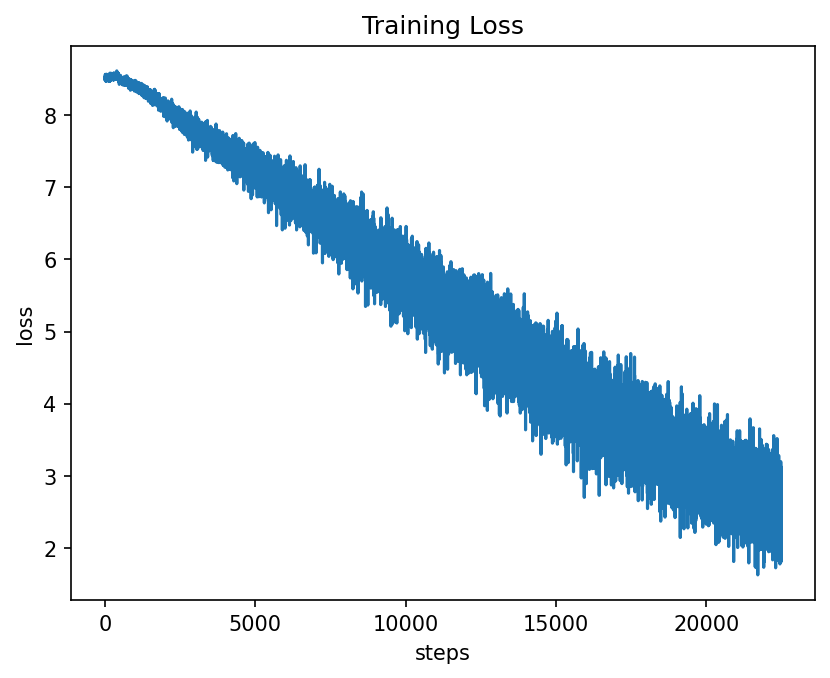

In [36]:
plt.rcParams['figure.dpi'] = 150
plt.plot(training_losses)
plt.xlabel('steps')
plt.ylabel('loss')
plt.title('Training Loss')
plt.savefig('./results/training_loss.png')

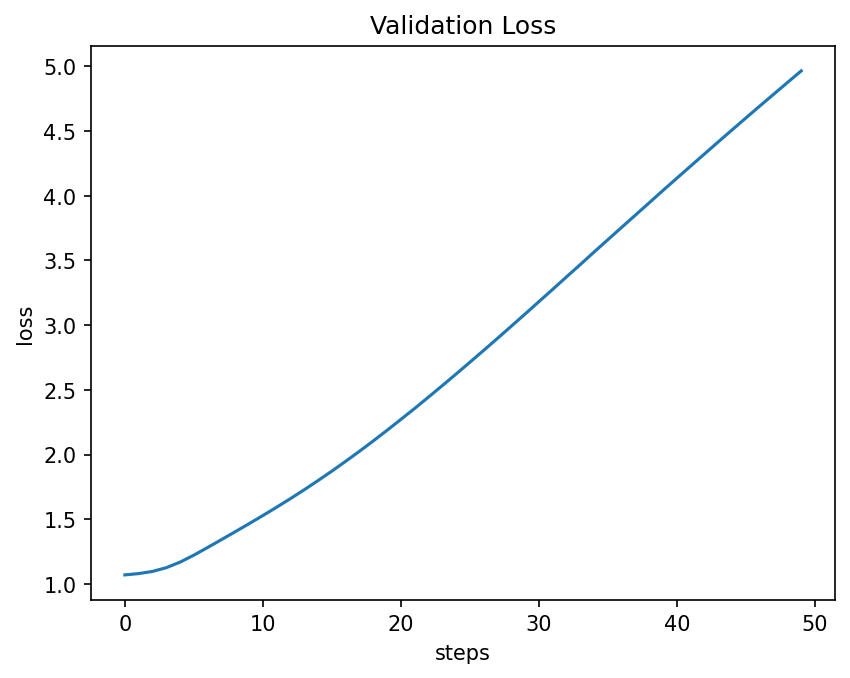

In [37]:
plt.plot(validation_losses)
plt.xlabel('steps')
plt.ylabel('loss')
plt.title('Validation Loss')
plt.savefig('./results/validation_loss.png')

### Writing
Belowe we want to analyze how the model functions based on the test data. What stands out from these results? Was the result correct? What is the main difference between the words?

What can be observed it that there are no target matches. However, the approach used in this model is essentially a bag-of-words but on a letter level - we only count the letter vectors, not the actual words and do not register any orded in the counts. Therefore, the observed behaviour is justified - the model learning the distribution of letters, not the sequence/orded of letters. This results in predicitons where words with similar letter counts are confused, such as "keep" and "week" where only one letter is changed. Secondly, we see that the model indetifies well words with the same endings (suffixes), such as "ing" which appears in 4 pairs: 
1. target: requesting,      predicted: interesting
2. target: improving,       predicted: impinging
3. target: patricia,       predicted: participating
4. target: moving,          predicted: grooming
Which is most likely due to those suffixes creating characteristic frequencies that the model learns. 

In [38]:
def get_n_words(dataset, n, model, ds, verbose = True):
    if n == -1:
        n = len(dataset)
    x = [dataset.__getitem__(i)[0] for i in range(n)]
    y = [dataset.__getitem__(i)[1] for i in range(n)]
    target_words = [{idx: word for word, idx in ds.word_to_idx.items()}[_.item()] for _ in y]
    out = [nn.functional.softmax(model(wrd)).argmax() for wrd in x]
    predicted_words = [{idx: word for word, idx in ds.word_to_idx.items()}[_.item()] for _ in out]
    width = max(len(word) for word in target_words) + 5
    if verbose:
        print('\n'.join([f'target: {t.ljust(width)} predicted: {p}' for t, p in zip(target_words, predicted_words)]))
    return target_words, predicted_words

_,_ = get_n_words(test_dataset, 10, model, dataset)

target: save              predicted: averages
target: basketball        predicted: valuable
target: acute             predicted: hackett
target: distribution      predicted: disturbing
target: marshall          predicted: small
target: compulsory        predicted: populous
target: guide             predicted: rigged
target: draught           predicted: thursday
target: or                predicted: brook
target: second            predicted: concluded


/var/folders/z3/h9qtkxfd38q8llwvssylbv8h0000gn/T/ipykernel_10542/2019737341.py:7: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  out = [nn.functional.softmax(model(wrd)).argmax() for wrd in x]


Why are some words incorrectly predicted?

All words are incorrectly predicted, because, as mentioned above, in the vectors the model only encodes the frequency of the letters in the each word, not their sequence. Therefore, there are no exact matches, but the predictions are close enough when looking at the frequencies of the letters in the pairs. The current representation is too simple, as it ignores the order of letters but also morphology, phonetics or semantics. To fix this, the model would need to be trained on a respresentation that also shows the order of letters and the context of words (for example a transformer) not just the count of letters.

### Code + Written
Research the Jaccard similarity metric for calculating the difference between the predicted word and the target word. Reference your sources and implement this metric in your code below. You can use the get_n_words function with n=-1 to get all the predicted and target words. Compare this method to similarity as measured with one of the word vector methods from A2, in writing and/or code.

[Your answer here]

The implementation is based on the two following sources:
* Source 1: Jaccard_score. (n.d.). Scikit-Learn. Retrieved 10 May 2026, from https://scikit-learn/stable/modules/generated/sklearn.metrics.jaccard_score.html
 https://scikit-learn.org/stable/modules/generated/sklearn.metrics.jaccard_score.html

 This package is not suitable for this application as for the vectors of len(26) it would treat each index as a separate class. But we want to check wheter the specific vectors have the same count in respective places in the vector.

* Source 2: Jadeja, M. (2024, March 5). Jaccard Similarity Made Simple: A Beginner’s Guide to Data Comparison. Medium. https://mayurdhvajsinhjadeja.medium.com/jaccard-similarity-34e2c15fb524


"Jaccard Similarity is a measure of similarity between two asymmetric binary vectors or we can say a way to find the similarity between two sets. [...] Index ranges from 0 to 1."



In [45]:
# Method 1 - based on (Jadeja, 2024)


def jaccard(dataset, n, model, ds, verbose = True):
    if n == -1:
        n = len(dataset)
    x = [dataset.__getitem__(i)[0] for i in range(n)]
    y = [dataset.__getitem__(i)[1] for i in range(n)]

    #we use the idx_to_word function so we break it up:
    idx_to_word= {idx: word for word, idx in ds.word_to_idx.items()}
    target_words = [idx_to_word[_.item()] for _ in y]

    out = [nn.functional.softmax(model(wrd)).argmax() for wrd in x]
    predicted_words = [idx_to_word[_.item()] for _ in out]

    width = max(len(word) for word in target_words) + 5

    def jaccard_similarity(target_word, pred_word):
        vector_target = torch.tensor(ds.word_to_vector(target_word))
        vector_predicted = torch.tensor(ds.word_to_vector(pred_word))

        # multiset Jaccard
        intersection = torch.min(vector_target, vector_predicted).sum().item() #iterate over each position and check for the min value -> create a new vector of the min values and sum them
        #this also accounts for cases where the words share one letter (e.g. 'a') but the other might have two "a's"
        union = torch.max(vector_target, vector_predicted).sum().item() #iterate over each position and record the max value in a new vector and sum them

        if union !=0:
            return intersection/union
        else:
            return 0.0

    if verbose:
        for t, p in zip(target_words, predicted_words):
            score_jaccard = jaccard_similarity(t,p)
            print('\n'.join([f'target: {t.ljust(width)}| predicted: {p}  |   jaccard similarity:{score_jaccard}']))
    return target_words, predicted_words

t,p = jaccard(test_dataset, 10, model, dataset)


target: save             | predicted: averages  |   jaccard similarity:0.5
target: basketball       | predicted: valuable  |   jaccard similarity:0.5
target: acute            | predicted: hackett  |   jaccard similarity:0.5
target: distribution     | predicted: disturbing  |   jaccard similarity:0.6923076923076923
target: marshall         | predicted: small  |   jaccard similarity:0.625
target: compulsory       | predicted: populous  |   jaccard similarity:0.5
target: guide            | predicted: rigged  |   jaccard similarity:0.5714285714285714
target: draught          | predicted: thursday  |   jaccard similarity:0.6666666666666666
target: or               | predicted: brook  |   jaccard similarity:0.4
target: second           | predicted: concluded  |   jaccard similarity:0.5


/var/folders/z3/h9qtkxfd38q8llwvssylbv8h0000gn/T/ipykernel_10542/4187295292.py:14: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  out = [nn.functional.softmax(model(wrd)).argmax() for wrd in x]


In [ ]:
# Method 2